In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Pick the best available device
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Matplotlib is building the font cache; this may take a moment.


Using device: mps


In [2]:
# Convert images to PyTorch tensors and normalize pixel values
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Download MNIST dataset (~10MB, downloads once)
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

# Look at one sample
image, label = train_data[0]
print(f"Image shape: {image.shape}")  # [1, 28, 28] = 1 channel, 28x28 pixels
print(f"Label: {label}")

100.0%
100.0%
100.0%
100.0%

Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])
Label: 5


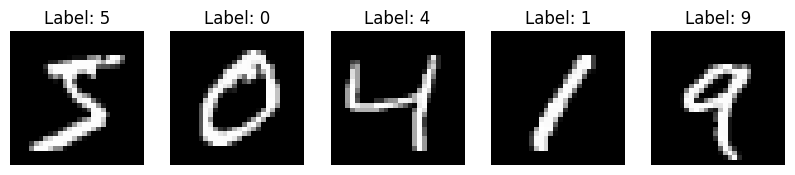

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    image, label = train_data[i]
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')
plt.show()

In [4]:
class FeedforwardNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()           # Turn 28x28 image into 784-vector
        self.fc1 = nn.Linear(784, 128)         # First layer: 784 -> 128
        self.fc2 = nn.Linear(128, 64)          # Second layer: 128 -> 64
        self.fc3 = nn.Linear(64, 10)           # Output layer: 64 -> 10 (one per digit)
        self.relu = nn.ReLU()                  # Activation function

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = FeedforwardNet().to(device)
print(model)

FeedforwardNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


In [5]:
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

loss_fn = nn.CrossEntropyLoss()  # Standard loss for classification
optimizer = optim.Adam(model.parameters(), lr=1e-3)  # Adam optimizer, learning rate 0.001

In [6]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Forward pass: predict
        predictions = model(images)
        loss = loss_fn(predictions, labels)

        # Backward pass: compute gradients and update weights
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} — avg loss: {avg_loss:.4f}")

print("Training done.")

Epoch 1/5 — avg loss: 0.2727
Epoch 2/5 — avg loss: 0.1127
Epoch 3/5 — avg loss: 0.0790
Epoch 4/5 — avg loss: 0.0613
Epoch 5/5 — avg loss: 0.0466
Training done.


In [7]:
model.eval()
correct = 0
total = 0

with torch.no_grad():  # Don't track gradients during evaluation (faster)
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        predictions = model(images)
        predicted_classes = predictions.argmax(dim=1)
        correct += (predicted_classes == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Test accuracy: {accuracy:.2f}%")

Test accuracy: 97.22%


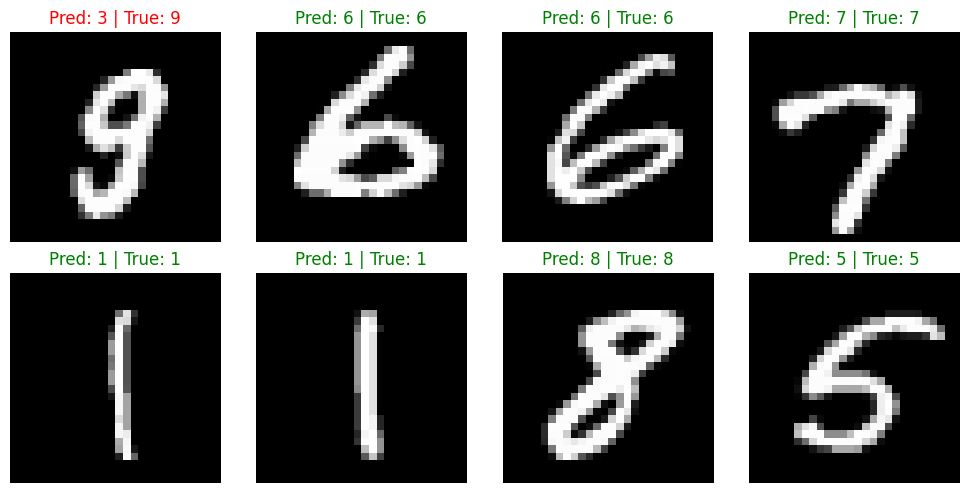

In [8]:
# Pick 8 random test images and show predictions
import random
indices = random.sample(range(len(test_data)), 8)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
model.eval()
with torch.no_grad():
    for i, idx in enumerate(indices):
        image, true_label = test_data[idx]
        prediction = model(image.unsqueeze(0).to(device)).argmax(dim=1).item()

        ax = axes[i // 4, i % 4]
        ax.imshow(image.squeeze(), cmap='gray')
        color = 'green' if prediction == true_label else 'red'
        ax.set_title(f"Pred: {prediction} | True: {true_label}", color=color)
        ax.axis('off')
plt.tight_layout()
plt.show()